In [1]:
import pandas as pd
from pathlib import Path

In [ ]:
BASE = Path(
    r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13"
)

RUTA_PROCESADOS = (
    BASE
    / "01_data"
    / "02_processed"
    / "prensa"
    / "articulos_con_texto"
)

print(RUTA_PROCESADOS.exists())

True


In [ ]:
for archivo in sorted(RUTA_PROCESADOS.glob("*_con_texto.csv")):
    print(archivo.name)

inmigracion_2015_con_texto.csv
inmigracion_2016_con_texto.csv
inmigracion_2019_con_texto.csv
inmigracion_2023_con_texto.csv
lgtb_2015_con_texto.csv
lgtb_2016_con_texto.csv
lgtb_2019_con_texto.csv
lgtb_2023_con_texto.csv


In [4]:
archivos = sorted(RUTA_PROCESADOS.glob("*_con_texto.csv"))

dataframes = []

for archivo in archivos:
    df_temp = pd.read_csv(archivo)

    nombre = archivo.stem

    if nombre.startswith("inmigracion"):
        tema = "inmigracion"
    elif nombre.startswith("lgtb"):
        tema = "lgtb"

    year = int(nombre.split("_")[1])

    df_temp["tema"] = tema
    df_temp["year_dataset"] = year

    dataframes.append(df_temp)

df_prensa = pd.concat(
    dataframes,
    ignore_index=True
)

print(df_prensa.shape)
df_prensa.head()

(94042, 12)


,id,publish_date,media_name,media_url,title,url,language,anio,mes,texto,tema,year_dataset
0,50859f6f441e40d325df5f31d22369451c2bc5a02fd23b...,2015-02-11,diariojaen.es,diariojaen.es,Golpe a la inmigraciÃ³n clandestina,https://www.diariojaen.es/historico/golpe-a-la...,es,2015,2,Golpe a la inmigración clandestina\nContra los...,inmigracion,2015
1,73033c3fd29d8952fc066c6c9295ad46dfcb7621568fad...,2015-01-09,diariojaen.es,diariojaen.es,Los Reyes Magos van en patera,https://www.diariojaen.es/historico/los-reyes-...,es,2015,1,Los Reyes Magos van en patera\nAquellos vetust...,inmigracion,2015
2,c8a983e636022993dd991c2d7e5ba58f378944c76aa3a7...,2015-02-16,diariojaen.es,diariojaen.es,Cae de manera drÃ¡stica la contrataciÃ³n de in...,https://www.diariojaen.es/historico/cae-de-man...,es,2015,2,Cae de manera drástica la contratación de inmi...,inmigracion,2015
3,d25f31e8b090909033d70dfaa3a6abc224781f4783a16c...,2015-04-22,diariojaen.es,diariojaen.es,La tragedia de la inmigraciÃ³n,https://www.diariojaen.es/historico/la-tragedi...,es,2015,4,La tragedia de la inmigración\nEl reciente nau...,inmigracion,2015
4,da0cd33371a533d51bbf141da1d3bb7606a1088a50fc0f...,2015-03-12,diariojaen.es,diariojaen.es,Hablando de inmigraciÃ³n,https://www.diariojaen.es/historico/hablando-d...,es,2015,3,Hablando de inmigración\nHace ya muchos siglos...,inmigracion,2015


## Distribución por tema y año

In [6]:
df_prensa.groupby(
    ["tema", "year_dataset"]
).size()

tema         year_dataset
inmigracion  2015            14333
             2016            15318
             2019            19546
             2023            22273
lgtb         2015             2741
             2016             3927
             2019             7269
             2023             8635
dtype: int64

In [7]:
df_prensa.shape

(94042, 12)

## Resumen de calidad por tema y año

In [8]:
resumen_calidad = (
    df_prensa
    .groupby(["tema", "year_dataset"])
    .agg(
        noticias=("url", "size"),
        textos_extraidos=("texto", lambda x: x.notna().sum()),
        tasa_exito=("texto", lambda x: x.notna().mean() * 100),
        longitud_media=("texto", lambda x: x.dropna().str.len().mean()),
        longitud_mediana=("texto", lambda x: x.dropna().str.len().median())
    )
    .reset_index()
)

resumen_calidad

,tema,year_dataset,noticias,textos_extraidos,tasa_exito,longitud_media,longitud_mediana
0,inmigracion,2015,14333,9701,67.682969,2880.215442,2469.0
1,inmigracion,2016,15318,11429,74.611568,2984.924315,2543.0
2,inmigracion,2019,19546,15285,78.200143,2715.969971,2281.0
3,inmigracion,2023,22273,20573,92.367440,3122.437710,2620.0
4,lgtb,2015,2741,1900,69.317767,2948.847368,2563.0
5,lgtb,2016,3927,2996,76.292335,3022.502336,2515.0
6,lgtb,2019,7269,5712,78.580272,2909.312850,2401.5
7,lgtb,2023,8635,7555,87.492762,3470.987558,2963.0


In [9]:
resumen_calidad["tasa_exito"] = resumen_calidad["tasa_exito"].round(2)
resumen_calidad["longitud_media"] = resumen_calidad["longitud_media"].round(0)
resumen_calidad["longitud_mediana"] = resumen_calidad["longitud_mediana"].round(0)

resumen_calidad

,tema,year_dataset,noticias,textos_extraidos,tasa_exito,longitud_media,longitud_mediana
0,inmigracion,2015,14333,9701,67.68,2880.0,2469.0
1,inmigracion,2016,15318,11429,74.61,2985.0,2543.0
2,inmigracion,2019,19546,15285,78.20,2716.0,2281.0
3,inmigracion,2023,22273,20573,92.37,3122.0,2620.0
4,lgtb,2015,2741,1900,69.32,2949.0,2563.0
5,lgtb,2016,3927,2996,76.29,3023.0,2515.0
6,lgtb,2019,7269,5712,78.58,2909.0,2402.0
7,lgtb,2023,8635,7555,87.49,3471.0,2963.0


## Resumen global por temática

In [10]:
resumen_tema = (
    df_prensa
    .groupby("tema")
    .agg(
        noticias=("url", "size"),
        textos_extraidos=("texto", lambda x: x.notna().sum()),
        tasa_exito=("texto", lambda x: x.notna().mean() * 100),
        longitud_media=("texto", lambda x: x.dropna().str.len().mean()),
        longitud_mediana=("texto", lambda x: x.dropna().str.len().median())
    )
    .reset_index()
)

resumen_tema["tasa_exito"] = resumen_tema["tasa_exito"].round(2)
resumen_tema["longitud_media"] = resumen_tema["longitud_media"].round(0)
resumen_tema["longitud_mediana"] = resumen_tema["longitud_mediana"].round(0)

resumen_tema

,tema,noticias,textos_extraidos,tasa_exito,longitud_media,longitud_mediana
0,inmigracion,71470,56988,79.74,2945.0,2483.0
1,lgtb,22572,18163,80.47,3166.0,2635.0


## Principales medios

In [12]:
top_inmigracion = (
    df_prensa[df_prensa["tema"] == "inmigracion"]
    ["media_name"]
    .value_counts()
    .head(20)
)

top_lgtb = (
    df_prensa[df_prensa["tema"] == "lgtb"]
    ["media_name"]
    .value_counts()
    .head(20)
)

print(top_inmigracion)
print()
print(top_lgtb)

media_name
abc.es                        4133
cope.es                       3622
elpais.com                    2345
elperiodico.com               2334
eldia.es                      2097
rtve.es                       1713
canarias7.es                  1689
europapress.es                1610
elperiodicoextremadura.com    1536
noticierouniversal.com        1511
publico.es                    1474
lavozdigital.es               1457
antena3.com                   1303
heraldo.es                    1232
farodevigo.es                 1217
elmundo.es                    1196
ideal.es                      1190
levante-emv.com               1096
laverdad.es                   1045
diariosur.es                  1026
Name: count, dtype: int64

media_name
abc.es                        1422
elpais.com                     905
elperiodico.com                714
lavozdigital.es                557
publico.es                     527
levante-emv.com                508
lavanguardia.com               477
elperi

## Noticias por año y tema

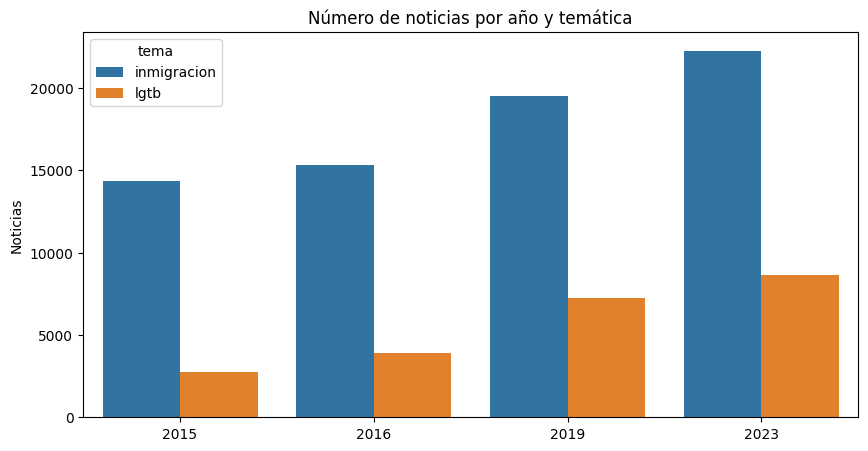

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.countplot(
    data=df_prensa,
    x="year_dataset",
    hue="tema"
)

plt.title("Número de noticias por año y temática")
plt.xlabel("")
plt.ylabel("Noticias")

plt.show()

## Tasa de éxito de extracción por tema y año

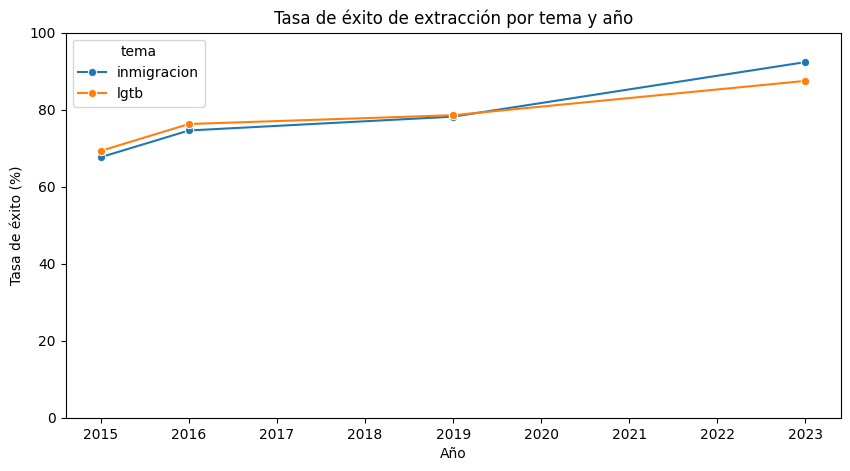

In [17]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=resumen_calidad,
    x="year_dataset",
    y="tasa_exito",
    hue="tema",
    marker="o"
)

plt.title("Tasa de éxito de extracción por tema y año")
plt.xlabel("Año")
plt.ylabel("Tasa de éxito (%)")
plt.ylim(0, 100)

plt.show()